# Library

In [7]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
import random 
import numpy as np
import pandas as pd
from torchinfo import summary
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from torch.utils.data import DataLoader, Dataset
import wandb
from dotenv import load_dotenv
from torchvision.datasets import DatasetFolder
from PIL import Image
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from torch.utils.data import random_split, Subset
import gc

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

from simdinov2.models.return_models import get_dino_finetuned_downloaded

# Loading Data

In [8]:
saved_dir = "AllPNG_Paddy25-03-2024-6Class"

In [9]:
# df_train = pd.read_csv(f"{saved_dir}/train3class.csv") 
# Load train and validation datasets

train = np.load(f"{saved_dir}/train_data.npz")
valid = np.load(f"{saved_dir}/val_data.npz")
test  = np.load(f"{saved_dir}/test_data.npz")

In [10]:

x_train = train['x_train']
y_train_keys = train['y_train']

x_valid = valid['x_val'] 
y_valid_keys = valid['y_val']

x_test = test['x_test']
y_test_keys = test['y_test']

In [11]:
np.unique(y_train_keys)

array(['PB1 Basmati', 'Pusa', 'Pusa 1121 Basmati', 'Pusa 1401 Basmati',
       'Pusa 1509 Basmati', 'Pusa 1718 Basmati', 'Sharbati Rice',
       'Sugandha Basmati', 'TAJ'], dtype='<U17')

In [12]:
Counter(y_train_keys)

Counter({np.str_('Pusa 1509 Basmati'): 17540,
         np.str_('Pusa 1718 Basmati'): 17428,
         np.str_('Pusa 1121 Basmati'): 17129,
         np.str_('Pusa 1401 Basmati'): 16369,
         np.str_('Sugandha Basmati'): 15262,
         np.str_('PB1 Basmati'): 4920,
         np.str_('Sharbati Rice'): 4619,
         np.str_('Pusa'): 4447,
         np.str_('TAJ'): 4363})

In [13]:
#Transform y values from keys to Breed, converting GK15 and ML105 to 'Mali'
def transform_breed(breed):
    return "Other" if breed not in ["Pusa 1509 Basmati", "Pusa 1121 Basmati", "Pusa 1718 Basmati", "Pusa 1401 Basmati", "Sugandha Basmati"] else breed
y_train = np.array([transform_breed(key) for key in y_train_keys])
y_valid = np.array([transform_breed(key) for key in y_valid_keys])
y_test = np.array([transform_breed(key) for key in y_test_keys ])

In [14]:
Counter(y_train), Counter(y_valid), Counter(y_test)

(Counter({np.str_('Other'): 18349,
          np.str_('Pusa 1509 Basmati'): 17540,
          np.str_('Pusa 1718 Basmati'): 17428,
          np.str_('Pusa 1121 Basmati'): 17129,
          np.str_('Pusa 1401 Basmati'): 16369,
          np.str_('Sugandha Basmati'): 15262}),
 Counter({np.str_('Other'): 4460,
          np.str_('Pusa 1121 Basmati'): 4029,
          np.str_('Pusa 1401 Basmati'): 4023,
          np.str_('Pusa 1718 Basmati'): 4016,
          np.str_('Pusa 1509 Basmati'): 3995,
          np.str_('Sugandha Basmati'): 2930}),
 Counter({np.str_('Pusa 1401 Basmati'): 4758,
          np.str_('Pusa 1121 Basmati'): 3988,
          np.str_('Sugandha Basmati'): 3843,
          np.str_('Pusa 1509 Basmati'): 3649,
          np.str_('Pusa 1718 Basmati'): 3611,
          np.str_('Other'): 3233}))

In [15]:
# Encode labels using Keras utilities
unique_classes = np.unique(y_train) # extract distinct classes
class_indices = {label: index for index, label in enumerate(unique_classes)} # class with index
y_train_encoded = np.array([class_indices[label] for label in y_train]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]
y_valid_encoded = np.array([class_indices[label] for label in y_valid]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]
y_test_encoded = np.array([class_indices[label] for label in y_test]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]

# Calculate class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = {index: weight for index, weight in enumerate(class_weights)}


In [16]:
class_indices

{np.str_('Other'): 0,
 np.str_('Pusa 1121 Basmati'): 1,
 np.str_('Pusa 1401 Basmati'): 2,
 np.str_('Pusa 1509 Basmati'): 3,
 np.str_('Pusa 1718 Basmati'): 4,
 np.str_('Sugandha Basmati'): 5}

In [17]:
intensity_ranges = {
        "brightness": np.linspace(0.9, 1.1, 5),  # Range should be >0
        "contrast": np.linspace(0.9, 1.1, 5),
        "saturation": np.linspace(0.9, 1.1, 5),  # Ensure positive values
        "hue": np.linspace(-0.05, 0.05, 5)  # Hue range should be (-0.5, 0.5)
        }

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image
    # transforms.RandomApply(
    # [transforms.ColorJitter(brightness=(intensity_ranges["brightness"].min(), intensity_ranges["brightness"].max()),
    #                         contrast=(intensity_ranges["contrast"].min(), intensity_ranges["contrast"].max()),
    #                         saturation=(intensity_ranges["saturation"].min(), intensity_ranges["saturation"].max()),
    #                         hue=(intensity_ranges["hue"].min(), intensity_ranges["hue"].max()))],
    #                         p=0.8,),
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize image
])

In [18]:
model_path = "IndiaPatch3Hovernet/eval/training_199999/teacher_checkpoint.pth" # full training
transformer = get_dino_finetuned_downloaded(model_path=model_path, modelname="dinov2_vitb14_reg")

Using cache found in /home/easyrice/.cache/torch/hub/facebookresearch_dinov2_main
/home/easyrice/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/easyrice/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/easyrice/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


In [19]:
def get_embeddings(data, model):
    embeddings = []

    for image in tqdm(data, desc="Extracting embeddings"):
        model.eval()
        with torch.no_grad():
            image = Image.fromarray(image) # Load image
            image = transform(image)  # Apply normalization
            image = image.unsqueeze(0) # Add batch dimension
            image = transformer(image.to("cuda"))
            embeddings.append(image.cpu().numpy())

    return np.array(embeddings)

In [20]:
train_embeddings = get_embeddings(x_train, transformer)
valid_embeddings = get_embeddings(x_valid, transformer)
test_embeddings = get_embeddings(x_test, transformer)

Extracting embeddings: 100%|██████████| 23082/23082 [02:28<00:00, 155.19it/s]


In [21]:
saved_dir = "embeddings/25March/hovernet/6class"
os.makedirs(saved_dir, exist_ok=True)

In [22]:
np.save(f"{saved_dir}/train_embeddings_6class_all_hovernet_IndianRice.npy", train_embeddings)
np.save(f"{saved_dir}/valid_embeddings_6class_all_hovernet_IndianRice.npy", valid_embeddings)
np.save(f"{saved_dir}/test_embeddings_6class_all_hovernet_IndianRice.npy", test_embeddings)

In [ ]:
train_embeddings = np.load("{saved_dir}/train_embeddings_6class_all_hovernet_IndianRice.npy")
valid_embeddings = np.load("{saved_dir}/valid_embeddings_6class_all_hovernet_IndianRice.npy")  
test_embeddings = np.load("{saved_dir}/test_embeddings_6class_all_hovernet_IndianRice.npy")

In [23]:
train_embeddings = torch.from_numpy(train_embeddings).float()
valid_embeddings = torch.from_numpy(valid_embeddings).float()
test_embeddings = torch.from_numpy(test_embeddings).float()

In [24]:
class CustomDataset(Dataset):
    def __init__(self, x_data, y_data, transform=None):
        self.x_data = x_data  # NumPy array of images embeddings
        self.y_data = y_data  # NumPy array of labels
        self.transform = transform

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):

        embeddings = self.x_data[idx]        
        label = self.y_data[idx]  # Get corresponding label

        return embeddings, torch.tensor(label, dtype=torch.long)

In [25]:
train_dataset = CustomDataset(train_embeddings, y_train_encoded, None)
valid_dataset = CustomDataset(valid_embeddings, y_valid_encoded, None)
test_dataset = CustomDataset(test_embeddings, y_test_encoded, None)

In [26]:
train_dataset[0][1].shape

torch.Size([])

In [27]:
train_embeddings.shape, y_train_encoded.shape

(torch.Size([102077, 1, 768]), (102077,))

In [28]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [29]:
for x, y in train_loader:
    print(x.shape, y.shape)
    # print(y)
    break

torch.Size([64, 1, 768]) torch.Size([64])


In [30]:
for x, y in val_loader:
    print(x.shape, y.shape)
    # print(y)
    break

torch.Size([64, 1, 768]) torch.Size([64])


# Transformer Model Initializing

In [31]:
# Multiclass classification model
class TransformerClassifier(pl.LightningModule):
    def __init__(self, num_classes=3, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        
        self.criterion = nn.CrossEntropyLoss()
        self.learning_rate = learning_rate

    def forward(self, x):
        x = x.squeeze(1) # squeeze the second dimension of the embeddings
        logits = self.classifier(x)
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        # Get predicted labels (taking the class with the highest probability)
        preds = torch.argmax(logits, dim=1)
    
        # Calculate accuracy: Number of correct predictions / Total number of predictions
        correct = (preds == y).sum().item()
        accuracy = correct / y.size(0)  # Divide by batch size to get accuracy

        self.log("train_loss", loss, prog_bar=True)
        wandb.log({"train_loss": loss, "train_acc": accuracy})
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        wandb.log({"val_loss": loss, "val_acc": acc})
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.classifier.parameters(), lr=self.learning_rate)

# Model training

In [32]:
dirpath = "checkpoints/25March/hovernet"
os.makedirs(dirpath, exist_ok=True)
filename = "best_model_6class_25MarchIndianRiceFinetunedSimDinoAllBreedHovernet"

In [ ]:
# Initialize model
classifier_model = TransformerClassifier(num_classes=6)

# Define the checkpoint callback
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',         # Monitor validation accuracy
    dirpath=dirpath,    # Directory to save the checkpoints
    filename=filename,     # Filename for the best model
    save_top_k=1,              # Save only the best model
    mode='max',                # We want the maximum validation accuracy
)
# Trainer setup
trainer = pl.Trainer(max_epochs=100, 
                     accelerator="gpu" if torch.cuda.is_available() else "mps",
                     callbacks=[checkpoint_callback])

load_dotenv()
wandb.login(key=os.getenv("WANDB_API_KEY"))
wandb.init(project="SIMDINOv2Classifier", name="train17 (6class Indian Rice, Transformer finetuned Hovernet all breeds full dataset)")
#Training
trainer.fit(classifier_model, train_loader, val_loader)

In [28]:
!wandb login --revoke

Usage: wandb login [OPTIONS] [KEY]...
Try 'wandb login --help' for help.

Error: No such option: --revoke


In [34]:
def predict_and_transform(model, val_loader):
    
    predictions = []
    

    # Disable gradient computation for inference
    model.to("cuda")
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            x_batch = batch[0].to("cuda")
            x_batch = x_batch.squeeze(1)
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1)  # Get the predicted class index for each sample
            predictions.extend(preds.cpu().numpy())  # Move back to CPU and store the predictions

    predicted_classes = np.array(predictions)

    
    return predicted_classes

In [35]:
dirpath, filename

('checkpoints/25March/hovernet',
 'best_model_6class_25MarchIndianRiceFinetunedSimDinoAllBreedHovernet')

In [36]:
classifier_model = TransformerClassifier.load_from_checkpoint(f"{dirpath}/{filename}.ckpt")
predicted_classes = predict_and_transform(classifier_model, test_loader)

del classifier_model # Delete the model to free up memory
gc.collect()

100

In [37]:
def plot_confusion_matrix_percentage(y_true, y_pred, class_labels):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_labels)))
    cm_percentage = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100  # Convert to percentage
    cm_percentage = np.nan_to_num(cm_percentage)  # Handle division by zero
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix (Percentage)->Hovernet Finetuned Embeddings')
    plt.show()

In [38]:
class_indices

{np.str_('Other'): 0,
 np.str_('Pusa 1121 Basmati'): 1,
 np.str_('Pusa 1401 Basmati'): 2,
 np.str_('Pusa 1509 Basmati'): 3,
 np.str_('Pusa 1718 Basmati'): 4,
 np.str_('Sugandha Basmati'): 5}

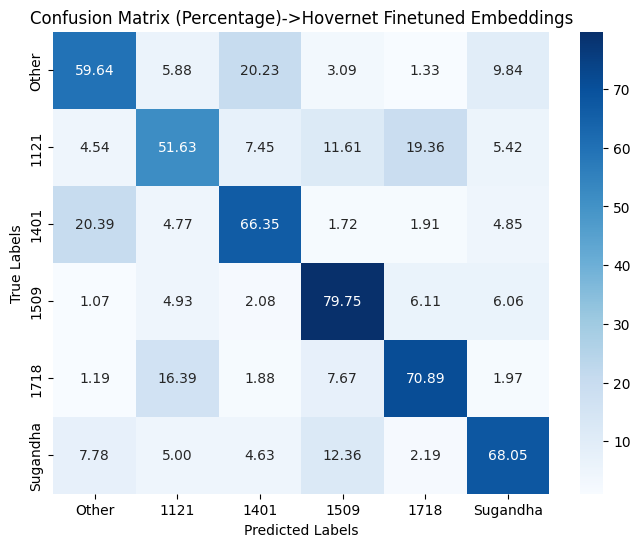

In [39]:
plot_confusion_matrix_percentage(y_test_encoded, predicted_classes, ['Other', '1121', '1401', '1509', '1718', 'Sugandha'])

In [40]:
y_test_keys

array(['Pusa 1509 Basmati', 'Pusa 1509 Basmati', 'Pusa 1509 Basmati', ...,
       'Pusa 1509 Basmati', 'Pusa 1509 Basmati', 'Pusa 1509 Basmati'],
      dtype='<U17')

In [41]:
class_indices

{np.str_('Other'): 0,
 np.str_('Pusa 1121 Basmati'): 1,
 np.str_('Pusa 1401 Basmati'): 2,
 np.str_('Pusa 1509 Basmati'): 3,
 np.str_('Pusa 1718 Basmati'): 4,
 np.str_('Sugandha Basmati'): 5}

In [44]:
import pandas as pd

idx_to_class = {v: k for k, v in class_indices.items()}
# Convert predicted class indices to actual class names
predicted_class_names = np.array([idx_to_class[idx] for idx in predicted_classes])
df = pd.DataFrame({'key_image_name': y_test_keys, 'prediction': predicted_class_names})

# Group by key_image_name and count prediction occurrences
result = df.groupby(['key_image_name', 'prediction']).size().unstack(fill_value=0)


In [45]:
result

prediction,Other,Pusa 1121 Basmati,Pusa 1401 Basmati,Pusa 1509 Basmati,Pusa 1718 Basmati,Sugandha Basmati
key_image_name,,,,,,
PB1 Basmati,565,48,246,11,10,75
Pusa,319,19,230,5,17,32
Pusa 1121 Basmati,181,2059,297,463,772,216
Pusa 1401 Basmati,970,227,3157,82,91,231
Pusa 1509 Basmati,39,180,76,2910,223,221
Pusa 1718 Basmati,43,592,68,277,2560,71
Sharbati Rice,583,5,45,4,0,16
Sugandha Basmati,299,192,178,475,84,2615
TAJ,461,118,133,80,16,195


In [46]:
result.to_csv("25March6Class.csv")